# ex-3 — pathwise formula (3.1), mono, composed on `fl_plot` (modern API remake)

The ex-3 figure set rebuilt from `fl_plot` marks only. Same three pathwise differences,
now as `Row(BoxDist)` compositions under `grid` — mono treatment first, then a
component-colored section (out-of-subspace blue) at the end. Composition-only: loads the
shared `ex2v2_df_{p,n}.parquet` cache (same spec as ex-2 v2); regenerate it there if
missing. Figures → `nb_outputs/mono-ex3-flplot/`.

Columns compared, per replicate:

- **left** — observable floor estimate $\hat\delta^2/(n\hat\lambda_{n,j}+\hat\delta^2)$
- **middle** — theoretical floor $\delta^2/(n\lambda_{n,j}+\delta^2)$
- **arg** — measured out-of-subspace mass $\Vert\Pi^{\perp}h_j\Vert^2$

In [40]:
import sys
from io import BytesIO
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "sim").is_dir():
    if REPO_ROOT == REPO_ROOT.parent:
        raise FileNotFoundError("could not locate repo root (no 'sim' dir above cwd)")
    REPO_ROOT = REPO_ROOT.parent
for _p in (str(REPO_ROOT), str(REPO_ROOT / "sim")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from fl_plot import grid, Row, BandStack, BoxDist, Theme, THEME

DATA_DIR = REPO_ROOT / "nb_outputs"
OUT_DIR = REPO_ROOT / "nb_outputs" / "ex3-flplot"
OUT_DIR.mkdir(parents=True, exist_ok=True)

FIG_FORMATS = ("pdf",)
SAVE_FIGS = False   # default: figures are NOT written to disk; enable one with out(..., save=True)


def out(stem, save=None):
    """out_path for grid(): OUT_DIR/stem when saving is on (globally via
    SAVE_FIGS, or per-figure via save=True), else None."""
    return OUT_DIR / stem if (SAVE_FIGS if save is None else save) else None


FACTOR_HATCHES = ("", "//", "xx", "..", "\\\\", "++")   # per-factor identity, colorless
MONO_THEME = Theme(factor_colors=("tab:gray",) * 6, factor_cmaps=("Greys",) * 6,
                   factor_hatches=FACTOR_HATCHES,
                   ci_caps=dict(fmt="none", ecolor="black", elinewidth=0.0, capsize=0))
_TAILS = r"(Factor Returns ~ $\mathcal{T}_6$, Idiosyncratic Returns ~ $\mathcal{T}_5$)"


def show(fig):
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    display(Image(data=buf.getvalue()))
    plt.close(fig)


def derive(df):
    left = df["observable_floor_estimate"]
    middle = df["floor"]
    arg = df["measured_out_of_subspace"]
    return df.assign(
        diff_left_middle=left - middle,   # observable estimate − theoretical floor
        diff_arg_left=arg - left,         # measured − observable estimate
        diff_middle_arg=middle - arg,     # theoretical floor − measured
        diff_left_arg=left - arg,         # observable estimate − measured
        diff_arg_middle=arg - middle,     # measured − theoretical floor
        ratio_ell_theta=(df["ell_bulk_eigenvalue_average"]
                         / df["theta_j_sample_eigenvalue"]),  # pathwise ℓ̂/θ̂
    )


In [41]:
# ── Sweep machinery, carried verbatim from ex-2 v2 / ex-3 (no .py files touched) ──
# Generates (or loads) the shared nb_outputs/ex2v2_df_{p,n}.parquet cache: same model,
# designs, and seed as ex-2/ex-3, so the replicates are identical across notebooks.
from fl_experiment_setup import ModelSpec, DesignSpec, BaseExperiment
from fl_experiment_runner import run_experiment
from sim_theorem_partii import Eq6RHSAnalysis
from factor_lab.analyses.spectral import compute_true_eigenvalues
from factor_lab.analyses import compute_sine_alignment

# Canonical diagonal-Gram model (factor 1 market-like, c = [1.25, 1, 1]).
model = ModelSpec(
    k_factors=3,
    factor_vols=[0.16, 0.08, 0.06],
    beta_samplers=[
        {"distribution": "normal", "loc": 1.0, "scale": 0.5},
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},
    ],
    idio_vol_sampler={"distribution": "constant", "value": 0.4},
)
HEAVY_TAIL = dict(
    factor_return_sampler={"distribution": "student_t", "df": 6, "loc": 0.0, "scale": 1.0},
    idio_return_sampler={"distribution": "student_t", "df": 5, "loc": 0.0, "scale": 1.0},
)
N_REPS, SEED = 1000, 20260511

design_p = DesignSpec(
    n_values=[63], p_values=[100, 500, 5000, 10000, 20000, 50000],
    n_reps=N_REPS, random_seed=SEED, sampling="nested", nest_time=True, **HEAVY_TAIL,
)
design_n = DesignSpec(
    n_values=[20, 30, 45, 60, 63, 90, 120, 180, 250], p_values=[3000],
    n_reps=N_REPS, random_seed=SEED, sampling="nested", nest_time=True, **HEAVY_TAIL,
)


class ObservableSpectrumAnalysis:
    """Observable side of Corollary 1: eigendecompose the n×n Gram G = Y^T Y, keep the full
    spectrum for the bulk average ℓ, and the top-k spikes θ_j (dual rescaled by 1/(n·p))."""

    def __init__(self, population_loading_directions_b_pop, center: bool = True):
        self.population_loading_directions_b_pop = population_loading_directions_b_pop
        self.center = center

    def analyze(self, context) -> dict:
        k = context.k
        Y = context.security_returns.T
        if self.center:
            Y = Y - Y.mean(axis=1, keepdims=True)
        p, n = Y.shape
        G = Y.T @ Y
        eigenvalues, eigenvectors = np.linalg.eigh(G)
        order = np.argsort(eigenvalues)[::-1]
        top_k = order[:k]
        sv = np.sqrt(np.maximum(eigenvalues[top_k], 0.0))
        H = (Y @ eigenvectors[:, top_k]) / np.where(sv > 1e-14, sv, 1.0)   # (p, k)
        sin2_angle, dist_sine = compute_sine_alignment(
            self.population_loading_directions_b_pop, H.T)

        dual = eigenvalues[order] / (n * p)
        theta = dual[:k]
        bulk = dual[k:n - 1] if self.center else dual[k:]
        ell = float(bulk.mean())
        return {"sin2_j": sin2_angle, "dist_sine": dist_sine,
                "sample_spike_eigenvalues_theta": theta,
                "sample_bulk_eigenvalue_average_ell": ell,
                "observable_floor_estimate": ell / theta}


class ObservableFloorExperiment(BaseExperiment):
    def __init__(self, center: bool = True):
        self.center = center

    def cell_setup(self, model, n: int, p: int):
        _, b_pop = compute_true_eigenvalues(model, model.k)
        return [ObservableSpectrumAnalysis(b_pop, center=self.center),
                Eq6RHSAnalysis(center=self.center)]

    def record(self, n: int, p: int, merged: dict) -> list[dict]:
        k = len(merged["sin2_j"])
        gap = merged["sin2_j"] - merged["rhs"]
        return [
            {"n": n, "p": p, "j": j + 1,
             "sin2_j": float(merged["sin2_j"][j]), "rhs": float(merged["rhs"][j]),
             "gap": float(gap[j]), "floor": float(merged["floor"][j]),
             "rotation": float(merged["rotation"][j]), "rho": float(merged["rhos"][j]),
             "theta_j_sample_eigenvalue": float(merged["sample_spike_eigenvalues_theta"][j]),
             "ell_bulk_eigenvalue_average": float(merged["sample_bulk_eigenvalue_average_ell"]),
             "observable_floor_estimate": float(merged["observable_floor_estimate"][j])}
            for j in range(k)]


class MeasuredDecompositionAnalysis(ObservableSpectrumAnalysis):
    """Adds the finite-p eq.(18) split: ‖Π⊥h_j‖² via projection of h_j onto col(b_pop)."""

    def analyze(self, context) -> dict:
        result = super().analyze(context)
        k = context.k
        Y = context.security_returns.T
        if self.center:
            Y = Y - Y.mean(axis=1, keepdims=True)
        G = Y.T @ Y
        eigenvalues, eigenvectors = np.linalg.eigh(G)
        top_k = np.argsort(eigenvalues)[::-1][:k]
        sv = np.sqrt(np.maximum(eigenvalues[top_k], 0.0))
        H = (Y @ eigenvectors[:, top_k]) / np.where(sv > 1e-14, sv, 1.0)
        coeffs = self.population_loading_directions_b_pop @ H           # (k, k)
        in_subspace = (coeffs ** 2).sum(axis=0)
        result["measured_out_of_subspace"] = 1.0 - in_subspace          # ‖Π⊥h_j‖²
        result["measured_in_subspace"] = result["sin2_j"] - (1.0 - in_subspace)
        result["angle_in_subspace"] = np.arccos(np.abs(np.diag(coeffs)) / np.sqrt(in_subspace))     # ∠(Π h_j, b_j), radians

        return result


class MeasuredDecompositionExperiment(ObservableFloorExperiment):
    def cell_setup(self, model, n: int, p: int):
        _, b_pop = compute_true_eigenvalues(model, model.k)
        return [MeasuredDecompositionAnalysis(b_pop, center=self.center),
                Eq6RHSAnalysis(center=self.center)]

    def record(self, n: int, p: int, merged: dict) -> list[dict]:
        rows = super().record(n, p, merged)
        for j, row in enumerate(rows):
            row["measured_out_of_subspace"] = float(merged["measured_out_of_subspace"][j])
            row["measured_in_subspace"] = float(merged["measured_in_subspace"][j])
            row["angle_in_subspace"] = float(merged["angle_in_subspace"][j])

        return rows


_pq_p, _pq_n = DATA_DIR / "ex2v2_df_p.parquet", DATA_DIR / "ex2v2_df_n.parquet"
if _pq_p.exists() and _pq_n.exists():
    df_p, df_n = pd.read_parquet(_pq_p), pd.read_parquet(_pq_n)
    print("loaded cached ex2v2 sweeps")
else:
    print("ex2v2 sweep cache missing — running sweeps (takes a few minutes)...")
    df_p = run_experiment(model, design_p, MeasuredDecompositionExperiment(), progress=True)
    df_n = run_experiment(model, design_n, MeasuredDecompositionExperiment(), progress=True)
    df_p.to_parquet(_pq_p)
    df_n.to_parquet(_pq_n)

df_p, df_n = derive(df_p), derive(df_n)
_SWEEPS = [(df_p, "p", "growing p, fixed n=63"), (df_n, "n", "growing n, fixed p=3000")]

for d, key, lab in _SWEEPS:
    print(f"{lab}: {int(d['rep'].max()) + 1} reps × {d[key].nunique()} {key}-values "
          f"× {d['j'].nunique()} factors")

loaded cached ex2v2 sweeps
growing p, fixed n=63: 1000 reps × 6 p-values × 3 factors
growing n, fixed p=3000: 1000 reps × 9 n-values × 3 factors


## Decomposition bands (context)

In [42]:
# not used in the paper — kept for reference, commented out
# for d, key, lab in _SWEEPS:
#     fig, _ = grid(d, key,
#         rows=[Row(BandStack(labels=("out-of-subspace", "in-subspace",
#                                     r"measured $\angle(h,\bar b)$")),
#                   ylabel=r"average $\sin^2$", ylim=(0, 1),
#                   yticks=THEME.sin2_ticks, height=1.0)],
#         theme=MONO_THEME,
#         suptitle=f"Decomposition — {lab} {_TAILS}",
#         formats=FIG_FORMATS, out_path=out(f"ex3_bands_{key}"))
#     show(fig)

## Pathwise differences — three-row grid

All rows are oriented estimate − "truth".

Row 1: left − middle (observable floor estimate − theoretical floor).
Row 2: left − arg (observable estimate − measured; what formula (3.1) bounds).
Row 3: middle − arg (theoretical floor − measured).

In [43]:
# not used in the paper — kept for reference, commented out
# _ROWS3 = [
#     Row(BoxDist("diff_left_middle"),
#         ylabel="$\\frac{\\hat\\delta^2}{n\\hat\\lambda+\\hat\\delta^2}"
#                " - \\frac{\\delta^2}{n\\lambda+\\delta^2}$\n[per rep]"),
#     Row(BoxDist("diff_left_arg"),
#         ylabel="$\\frac{\\hat\\delta^2}{n\\hat\\lambda+\\hat\\delta^2}"
#                " - \\Vert\\Pi^{\\perp}h_j\\Vert^2$\n[per rep]"),
#     Row(BoxDist("diff_middle_arg"),
#         ylabel="$\\frac{\\delta^2}{n\\lambda+\\delta^2}"
#                " - \\Vert\\Pi^{\\perp}h_j\\Vert^2$\n[per rep]"),
# ]
# for d, key, lab in _SWEEPS:
#     fig, _ = grid(d, key, rows=_ROWS3, theme=MONO_THEME,
#         suptitle=f"Pathwise formula (3.1) differences — {lab} {_TAILS}",
#         formats=FIG_FORMATS, out_path=out(f"ex3_grid3_{key}"))
#     show(fig)

## Two-row variant (shared y)

In [44]:
# not used in the paper — kept for reference, commented out
# _ROWS2 = [
#     Row(BoxDist("diff_left_middle"),
#         ylabel="$\\frac{\\hat\\delta^2}{n\\hat\\lambda+\\hat\\delta^2}"
#                " - \\frac{\\delta^2}{n\\lambda+\\delta^2}$\n[per rep]"),
#     Row(BoxDist("diff_left_arg"),
#         ylabel="$\\frac{\\hat\\delta^2}{n\\hat\\lambda+\\hat\\delta^2}"
#                " - \\Vert\\Pi^{\\perp}h_j\\Vert^2$\n[per rep]"),
# ]
# for d, key, lab in _SWEEPS:
#     fig, _ = grid(d, key, rows=_ROWS2, sharey=True, theme=MONO_THEME,
#         suptitle=f"Observable-floor errors, shared scale — {lab} {_TAILS}",
#         formats=FIG_FORMATS, out_path=out(f"ex3_grid2_{key}"))
#     show(fig)

## Single difference: observable estimate − measured

In [45]:
# not used in the paper — kept for reference, commented out
# _ROWS1 = [Row(BoxDist("diff_left_arg"),
#               ylabel="$\\frac{\\hat\\delta^2}{n\\hat\\lambda+\\hat\\delta^2}"
#                      " - \\Vert\\Pi^{\\perp}h_j\\Vert^2$\n[per rep]", height=1.0)]
# for d, key, lab in _SWEEPS:
#     fig, _ = grid(d, key, rows=_ROWS1, sharey=True, theme=MONO_THEME,
#         suptitle=f"Observable estimate vs measured — {lab} {_TAILS}",
#         formats=FIG_FORMATS, out_path=out(f"ex3_grid1_{key}"))
#     show(fig)

## Summary numbers

In [46]:
def summary(d, key):
    g = d.groupby([key, "j"])
    out = g[["diff_left_middle", "diff_left_arg", "diff_middle_arg"]].median()
    out.columns = [f"med {c}" for c in out.columns]
    out["IQR diff_left_arg"] = (g["diff_left_arg"].quantile(0.75)
                                - g["diff_left_arg"].quantile(0.25))
    return out.round(4)

for d, key, lab in _SWEEPS:
    print(f"--- {lab} ---")
    display(summary(d, key))

--- growing p, fixed n=63 ---


med diff_left_middle  med diff_left_arg  med diff_middle_arg  \
p     j                                                                 
100   1               -0.0070            -0.0081              -0.0007   
      2               -0.0754            -0.1597              -0.0870   
      3               -0.1583            -0.4249              -0.2680   
500   1               -0.0016            -0.0016              -0.0002   
      2               -0.0179            -0.0318              -0.0144   
      3               -0.0426            -0.0922              -0.0501   
5000  1               -0.0001            -0.0002              -0.0000   
      2               -0.0018            -0.0033              -0.0015   
      3               -0.0040            -0.0087              -0.0051   
10000 1               -0.0001            -0.0001              -0.0000   
      2               -0.0012            -0.0019              -0.0008   
      3               -0.0021            -0.0046              -0.0025   
20000 1               -0.0000            -0.0001              -0.0000   
      2               -0.0005            -0.0009              -0.0005   
      3               -0.0013            -0.0024              -0.0008   
50000 1               -0.0000            -0.0000              -0.0000   
      2               -0.0002            -0.0003              -0.0001   
      3               -0.0004            -0.0008              -0.0006   

         IQR diff_left_arg  
p     j                     
100   1             0.0164  
      2             0.1339  
      3             0.2462  
500   1             0.0072  
      2             0.0325  
      3             0.0744  
5000  1             0.0024  
      2             0.0086  
      3             0.0140  
10000 1             0.0017  
      2             0.0065  
      3             0.0094  
20000 1             0.0011  
      2             0.0040  
      3             0.0065  
50000 1             0.0007  
      2             0.0029  
      3             0.0039

--- growing n, fixed p=3000 ---


med diff_left_middle  med diff_left_arg  med diff_middle_arg  \
n   j                                                                 
20  1               -0.0008            -0.0011              -0.0007   
    2               -0.0068            -0.0123              -0.0063   
    3               -0.0181            -0.0343              -0.0182   
30  1               -0.0006            -0.0006              -0.0001   
    2               -0.0048            -0.0092              -0.0054   
    3               -0.0124            -0.0250              -0.0142   
45  1               -0.0004            -0.0005              -0.0001   
    2               -0.0033            -0.0067              -0.0035   
    3               -0.0089            -0.0187              -0.0107   
60  1               -0.0003            -0.0003              -0.0001   
    2               -0.0029            -0.0056              -0.0027   
    3               -0.0075            -0.0159              -0.0080   
63  1               -0.0002            -0.0004              -0.0002   
    2               -0.0027            -0.0054              -0.0024   
    3               -0.0073            -0.0148              -0.0079   
90  1               -0.0002            -0.0002              -0.0001   
    2               -0.0021            -0.0037              -0.0018   
    3               -0.0051            -0.0108              -0.0058   
120 1               -0.0001            -0.0002               0.0000   
    2               -0.0016            -0.0029              -0.0016   
    3               -0.0043            -0.0086              -0.0045   
180 1               -0.0001            -0.0001              -0.0000   
    2               -0.0012            -0.0020              -0.0008   
    3               -0.0031            -0.0060              -0.0031   
250 1               -0.0000            -0.0001              -0.0000   
    2               -0.0008            -0.0015              -0.0008   
    3               -0.0022            -0.0047              -0.0022   

       IQR diff_left_arg  
n   j                     
20  1             0.0093  
    2             0.0244  
    3             0.0404  
30  1             0.0064  
    2             0.0193  
    3             0.0328  
45  1             0.0040  
    2             0.0155  
    3             0.0231  
60  1             0.0028  
    2             0.0118  
    3             0.0180  
63  1             0.0027  
    2             0.0113  
    3             0.0176  
90  1             0.0020  
    2             0.0087  
    3             0.0131  
120 1             0.0015  
    2             0.0069  
    3             0.0112  
180 1             0.0010  
    2             0.0045  
    3             0.0078  
250 1             0.0007  
    2             0.0034  
    3             0.0056

---
## Component-colored versions

All differences here are out-of-subspace quantities, so the whole section uses the
out-of-subspace blue from the component palette.

In [47]:
# not used in the paper — kept for reference, commented out
# OOS_T = Theme(factor_colors=("#4878a8",) * 6, factor_cmaps=("Blues",) * 6,
#               factor_hatches=FACTOR_HATCHES,
#               ci_caps=dict(fmt="none", ecolor="black", elinewidth=0.0, capsize=0))
#
# for d, key, lab in _SWEEPS:
#     fig, _ = grid(d, key, rows=_ROWS3, theme=OOS_T,
#         suptitle=f"Pathwise formula (3.1) differences — {lab} {_TAILS}",
#         formats=FIG_FORMATS, out_path=out(f"ex3_grid3_{key}_qcolor"))
#     show(fig)
#     fig, _ = grid(d, key, rows=_ROWS2, sharey=True, theme=OOS_T,
#         suptitle=f"Observable-floor errors, shared scale — {lab} {_TAILS}",
#         formats=FIG_FORMATS, out_path=out(f"ex3_grid2_{key}_qcolor"))
#     show(fig)
#     fig, _ = grid(d, key, rows=_ROWS1, sharey=True, theme=OOS_T,
#         suptitle=f"Observable estimate vs measured — {lab} {_TAILS}",
#         formats=FIG_FORMATS, out_path=out(f"ex3_grid1_{key}_qcolor"))
#     show(fig)

---
## Out-of-subspace levels over the growing-p boxplots

Top row: the ex-2 out-of-subspace top row, verbatim — theoretical floor
$\delta^2/(n\lambda_{n,j}+\delta^2)$ (band) and measured $\Vert\Pi^{\perp}h_j\Vert^2$
(dots, mean across reps), plus the mean pathwise ratio $\hat\ell/\hat\theta_j$ in red.
Bottom row: the same growing-p observable-estimate − measured boxplots as the
single-difference figure above.

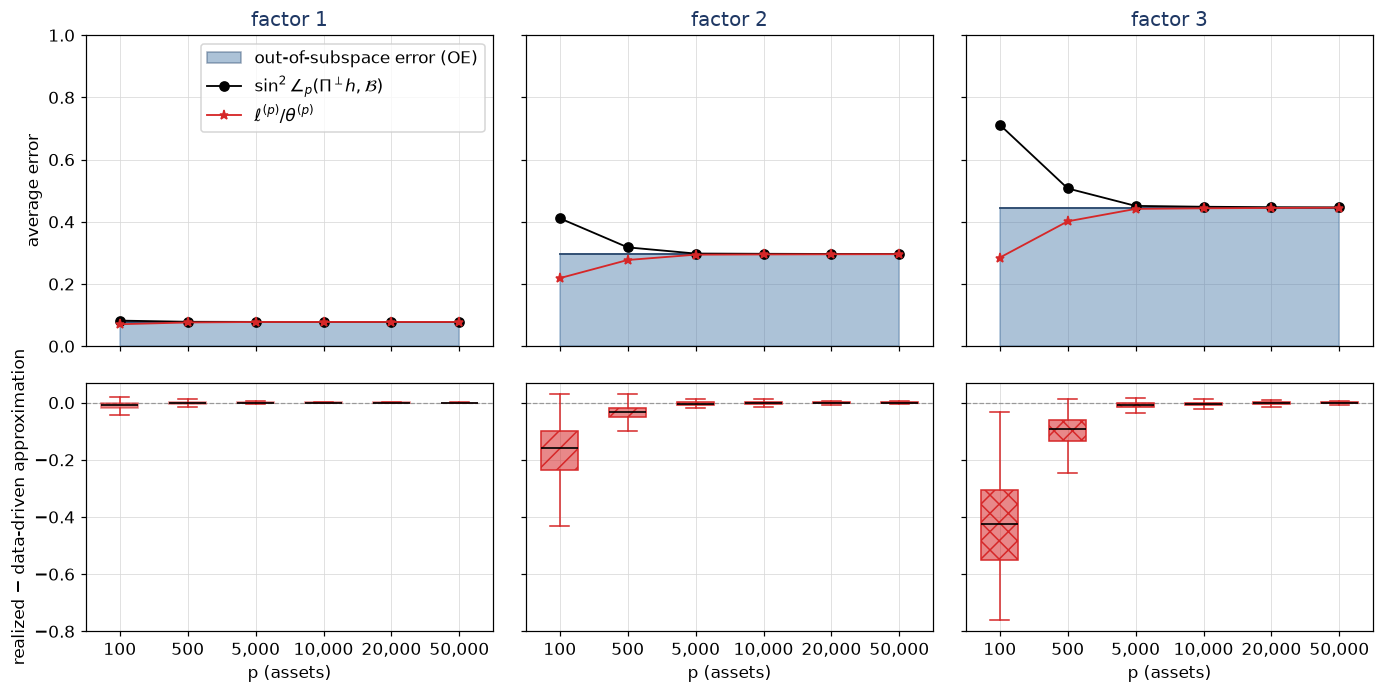

In [48]:
from fl_plot import Band, MeanCI
diff_boxplot_theme = Theme(factor_colors=("tab:red",) * 6, factor_cmaps=("Reds",) * 6,
                   factor_hatches=FACTOR_HATCHES,
                   ci_caps=dict(fmt="none", ecolor="black", elinewidth=0.0, capsize=0))
fig, _ = grid(df_p, "p",
    rows=[Row([Band("floor", label="out-of-subspace error (OE)"),
               MeanCI("measured_out_of_subspace",
                    #   label=r"measured $\Vert\Pi^{\perp}h_j\Vert^2$")],
                    label=r"$\sin^2\angle_p(\Pi^{\perp}h,\mathcal{B})$"),
               MeanCI("ratio_ell_theta", 
                    #   label=r"mean $\hat\ell/\hat\theta_j$",
                    label=r"$\ell^{(p)}/\theta^{(p)}$",
                      color="tab:red", marker="*",
                    #   caption=r"red dots = mean $\hat\ell/\hat\theta_j$ over replicates")],
                    )],ylim=(0,1),
            #   ylabel=r"out-of-subspace $\Vert\Pi^{\perp}h_j\Vert^2$", height=1.0),
            ylabel="average error", height=1.0),
          Row(BoxDist("diff_left_arg"),
              ylabel="realized − data-driven approximation")],
                    #  " - \\Vert\\Pi^{\\perp}h_j\\Vert^2$\n[per rep]")],
    theme=diff_boxplot_theme,
    caption=False,
    # suptitle=f"Out-of-Subspace — growing p, fixed n=63 {_TAILS}",
    formats=FIG_FORMATS, out_path=out("ex3_oos_levels_p", save=True))
show(fig)

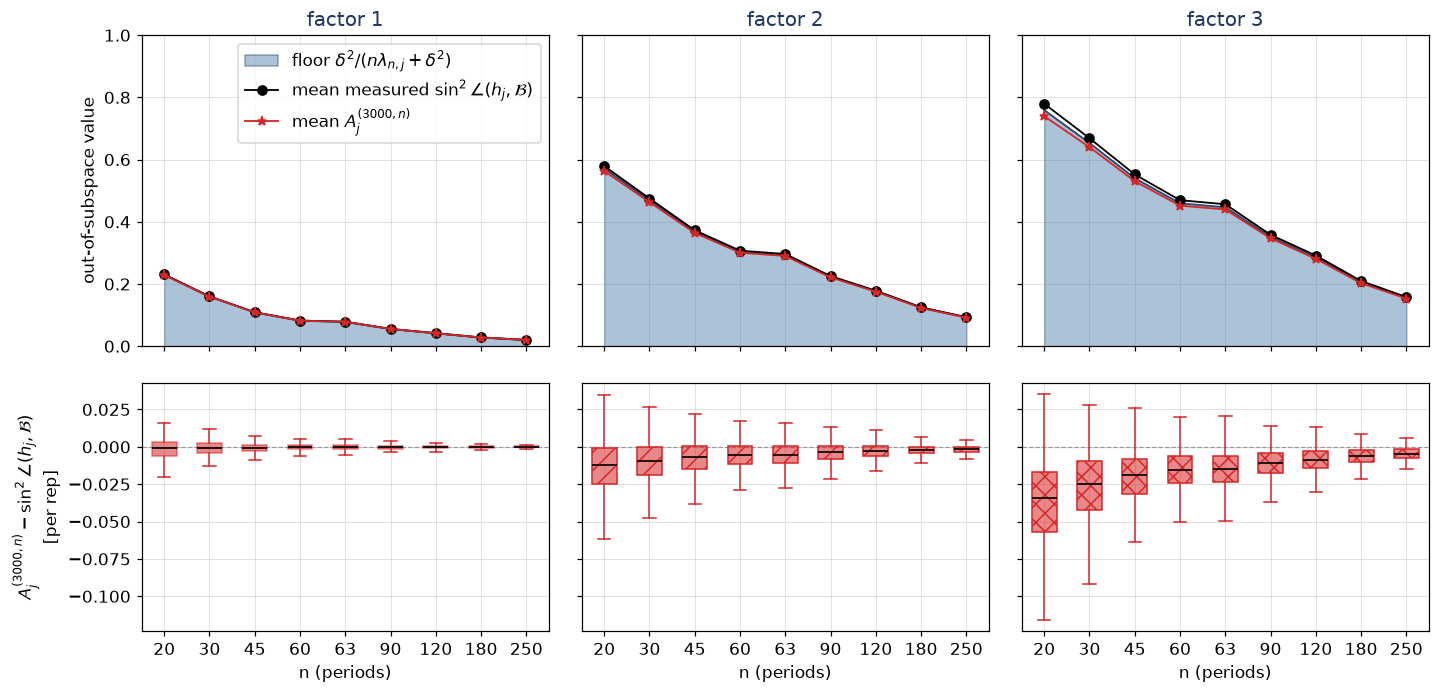

In [49]:
from fl_plot import Band, MeanCI

fig, _ = grid(df_n, "n",
    rows=[Row([Band("floor", label=r"floor $\delta^2/(n\lambda_{n,j}+\delta^2)$"),
               MeanCI("measured_out_of_subspace",
                    #   label=r"measured $\Vert\Pi^{\perp}h_j\Vert^2$")],
                    label=r"mean measured $\sin^2\angle(h_j,\mathcal{B})$"),
               MeanCI("ratio_ell_theta", 
                    #   label=r"mean $\hat\ell/\hat\theta_j$",
                    label=r"mean $A_j^{(3000,n)}$",
                      color="tab:red", marker="*",
                    #   caption=r"red dots = mean $\hat\ell/\hat\theta_j$ over replicates")],
                    )],ylim=(0,1),
            #   ylabel=r"out-of-subspace $\Vert\Pi^{\perp}h_j\Vert^2$", height=1.0),
            ylabel=r"out-of-subspace value", height=1.0),
          Row(BoxDist("diff_left_arg"),
              ylabel="$A_j^{(3000,n)} - \\sin^2\\angle(h_j,\\mathcal{B})$\n[per rep]")],
                    #  " - \\Vert\\Pi^{\\perp}h_j\\Vert^2$\n[per rep]")],
    theme=diff_boxplot_theme,
    caption=False,
    # suptitle=f"Out-of-Subspace — growing n, fixed p=3000 {_TAILS}",
    formats=FIG_FORMATS, out_path=out("ex3_oos_levels_n", save=True))
show(fig)

## Levels figures, angle-unit error row (new versions — originals kept above)

Same top row; the bottom boxplot row is the **pathwise angle error** in degrees:
$\arcsin\sqrt{A_j} - \arcsin\sqrt{\Vert\Pi^{\perp}h_j\Vert^2}$, paired within each
replicate. The $\arcsin\sqrt{\cdot}$ transform is variance-stabilizing, so the three
factors' boxes are on a comparable scale.

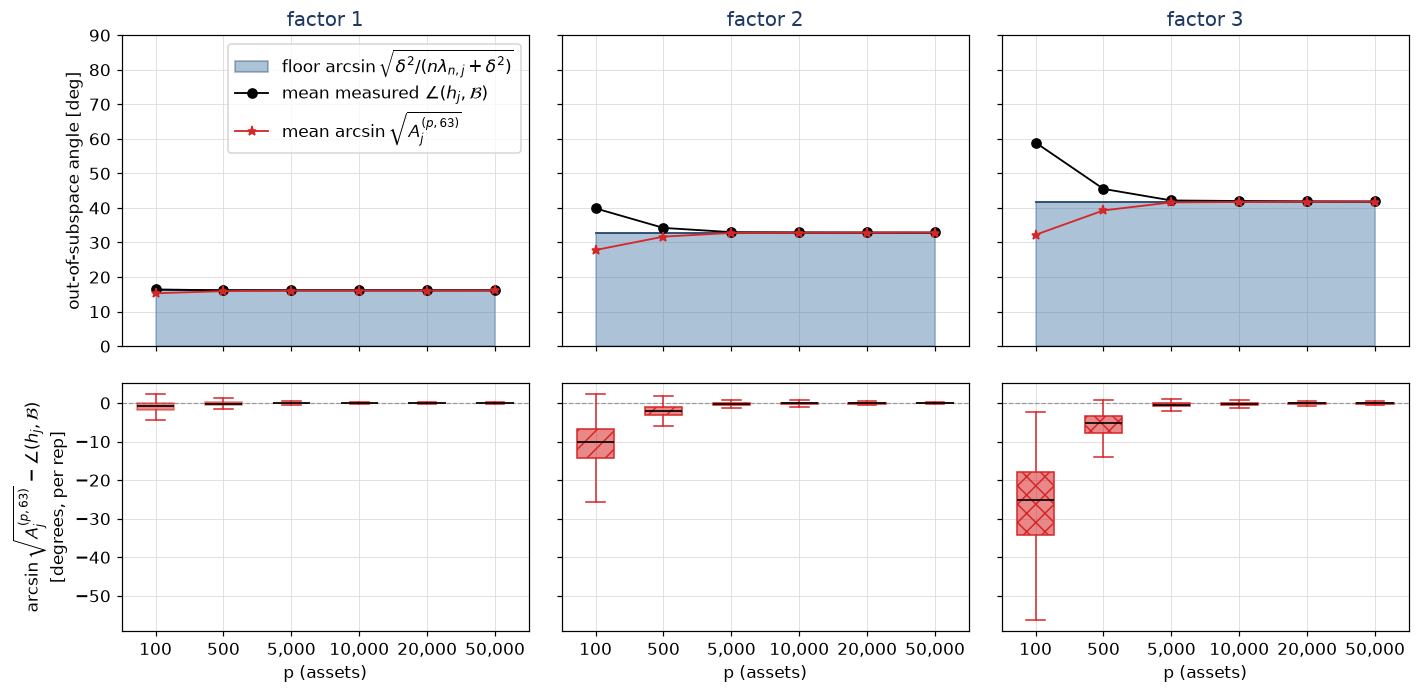

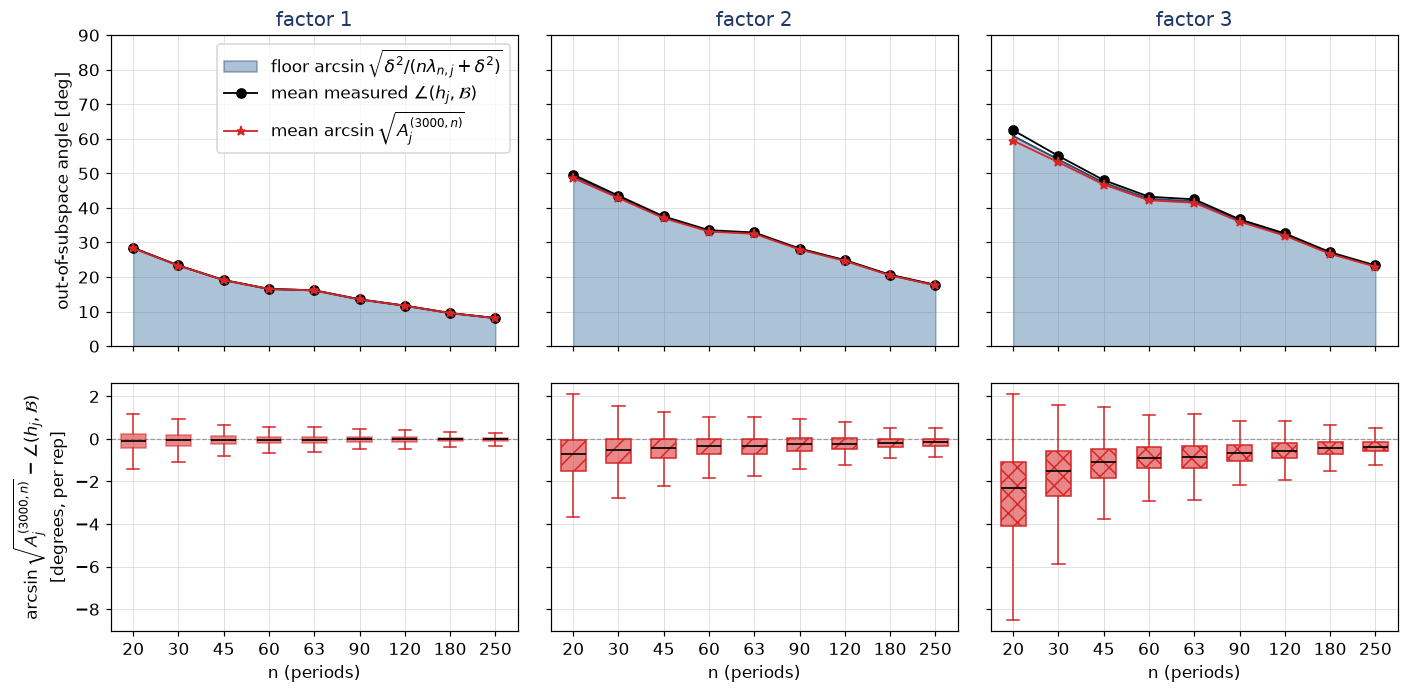

In [50]:
_A_SUP = {"p": r"A_j^{(p,63)}", "n": r"A_j^{(3000,n)}"}
def _deg(x): return np.degrees(np.arcsin(np.sqrt(x)))
for d, key, lab in _SWEEPS:
    d_ang = d.assign(
        floor_deg=_deg(d["floor"]),
        oos_deg=_deg(d["measured_out_of_subspace"]),
        A_deg=_deg(d["ratio_ell_theta"]),
        ang_err=_deg(d["observable_floor_estimate"]) - _deg(d["measured_out_of_subspace"]))
    fig, _ = grid(d_ang, key,
        rows=[Row([Band("floor_deg",
                        label=r"floor $\arcsin\sqrt{\delta^2/(n\lambda_{n,j}+\delta^2)}$"),
                   MeanCI("oos_deg",
                          label=r"mean measured $\angle(h_j,\mathcal{B})$"),
                   MeanCI("A_deg", label=rf"mean $\arcsin\sqrt{{{_A_SUP[key]}}}$",
                          color="tab:red", marker="*")],
                  ylim=(0, 90), ylabel=r"out-of-subspace angle [deg]", height=1.0),
              Row(BoxDist("ang_err"),
                  ylabel=rf"$\arcsin\sqrt{{{_A_SUP[key]}}} - \angle(h_j,\mathcal{{B}})$"
                         + "\n[degrees, per rep]")],
        theme=diff_boxplot_theme,
        caption=False,
        formats=FIG_FORMATS, out_path=out(f"ex3_oos_levels_{key}_deg", save=True))
    show(fig)

## Levels figures, median version (transform-equivariant)

Same as above but median-based: Q1–Q3 band + median line across replicates, for both the
measured angle and $\arcsin\sqrt{A_j}$. Medians commute with monotone transforms, so this
summary is identical whether computed on the $\sin^2$ or the angle scale — the robust
choice that sidesteps the mean-angle vs angle-of-mean convention entirely. Bottom row
unchanged (boxplots are already median-centric).

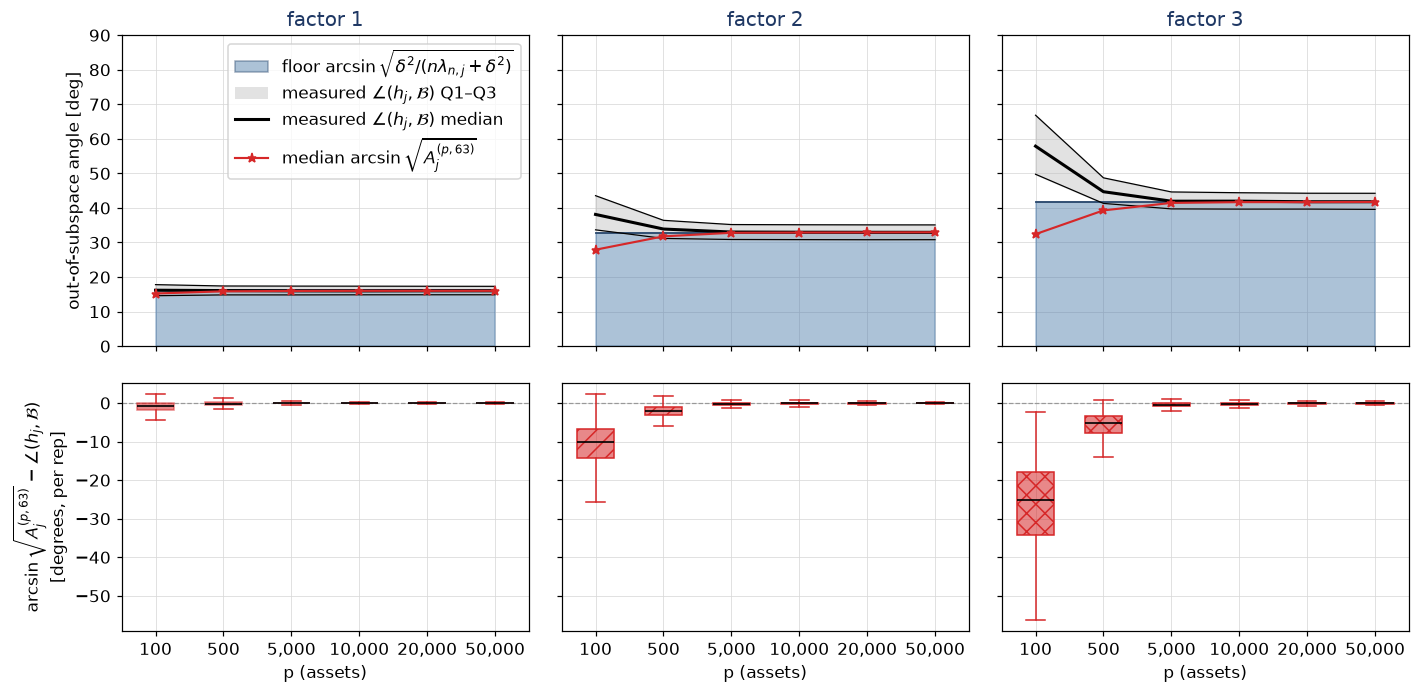

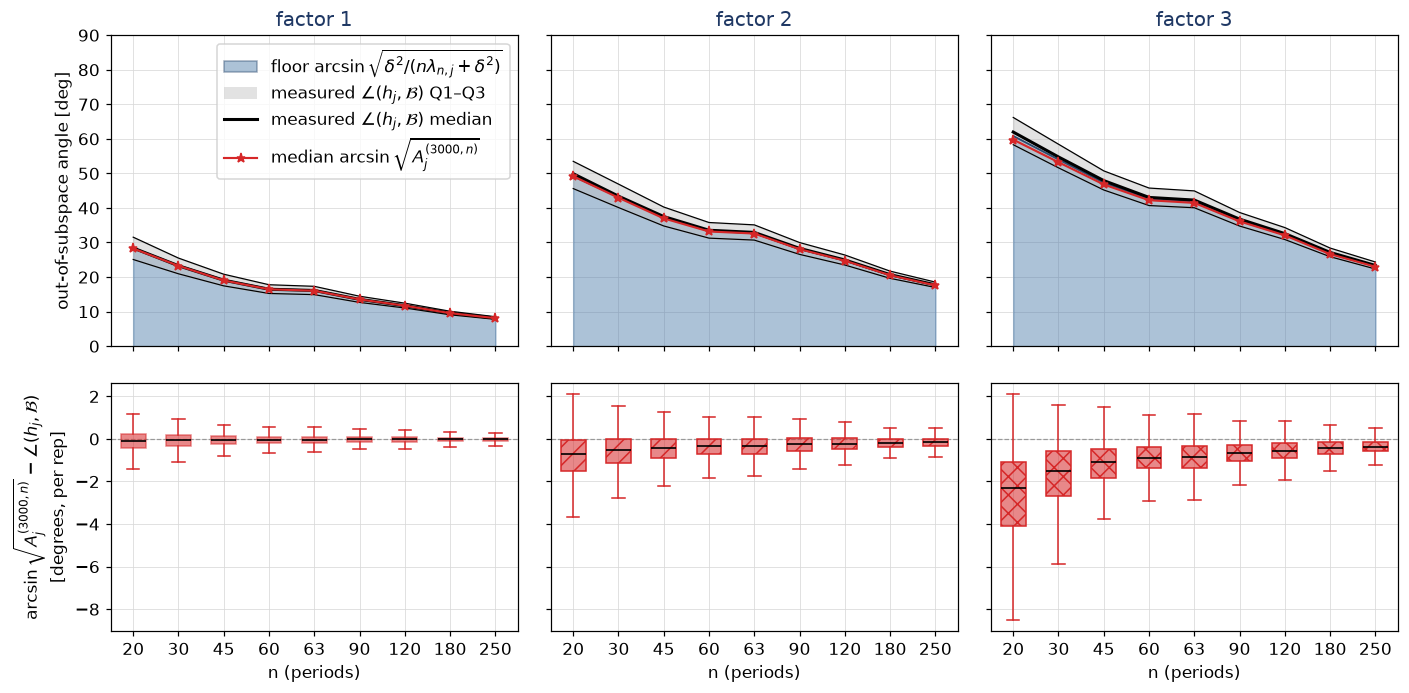

In [51]:
from fl_plot import QuantileBand, summarize


class MedianLine:
    """Median-across-replicates line of ``col`` — the transform-equivariant
    counterpart of MeanCI, without a band."""

    caption = "line = median across replicates"

    def __init__(self, col, *, label=None, color="black", marker=None):
        self.col, self.label, self.color, self.marker = col, label, color, marker

    def draw(self, ax, ax_spec, sub, j_idx, theme):
        a = summarize(sub, ax_spec, self.col)
        ax.plot(ax_spec.x, a["median"].to_numpy(), marker=self.marker, ls="-",
                color=self.color, lw=1.4, zorder=5)
        ax.set_xlim(ax_spec.x[0], ax_spec.x[-1])
        ax.set_xticks(ax_spec.x, ax_spec.cats, fontsize=theme.tick_fontsize)

    def legend_handles(self, theme):
        return [plt.Line2D([], [], marker=self.marker, color=self.color, lw=1.4,
                           label=self.label or self.col)]


for d, key, lab in _SWEEPS:
    d_ang = d.assign(
        floor_deg=_deg(d["floor"]),
        oos_deg=_deg(d["measured_out_of_subspace"]),
        A_deg=_deg(d["ratio_ell_theta"]),
        ang_err=_deg(d["observable_floor_estimate"]) - _deg(d["measured_out_of_subspace"]))
    fig, _ = grid(d_ang, key,
        rows=[Row([Band("floor_deg",
                        label=r"floor $\arcsin\sqrt{\delta^2/(n\lambda_{n,j}+\delta^2)}$"),
                   QuantileBand("oos_deg", label=r"measured $\angle(h_j,\mathcal{B})$",
                                fill="0.75", line="black"),
                   MedianLine("A_deg", label=rf"median $\arcsin\sqrt{{{_A_SUP[key]}}}$",
                              color="tab:red", marker="*")],
                  ylim=(0, 90), ylabel=r"out-of-subspace angle [deg]", height=1.0),
              Row(BoxDist("ang_err"),
                  ylabel=rf"$\arcsin\sqrt{{{_A_SUP[key]}}} - \angle(h_j,\mathcal{{B}})$"
                         + "\n[degrees, per rep]")],
        theme=diff_boxplot_theme,
        caption=False,
        formats=FIG_FORMATS, out_path=out(f"ex3_oos_levels_{key}_deg_median", save=True))
    show(fig)

---
## Change log

- **2026-08-13**: modern-API remake of the mono ex-3 figure set — every figure composed
  from `fl_plot` marks (`BandStack`/`BoxDist` rows under `grid`), mono +
  component-colored sections. Composition-only: data from the shared ex2v2 cache.
- **2026-08-13**: gray boxes with per-factor hatching; new bottom figure — out-of-subspace levels (observable estimate band + measured mean) over the growing-p difference boxplots.


## Mean out-of-subspace angles

The levels figures in angle units, per factor × swept value: mean over replicates of
$\arcsin\sqrt{\cdot}$ in degrees, for the measured out-of-subspace mass
$\Vert\Pi^{\perp}h_j\Vert^2$ and for the observable estimate
$A_j = \hat\ell/\hat\theta_j$. Growing p locks each factor onto its floor angle almost
immediately; growing n walks the angles down with no floor.

The third table is the **mean pathwise angle error**: mean over replicates of
$\arcsin\sqrt{A_j} - \angle(h_j,\mathcal{B})$, paired within replicate — goes to 0 in
p, and stays near 0 across all n.

In [52]:
def angle_table(d, key, col):
    ang = np.degrees(np.arcsin(np.sqrt(d[col])))
    t = ang.groupby([d[key], d["j"]]).mean().round(1).unstack("j")
    t.columns = [f"factor {j}" for j in t.columns]
    return t


for d, key, lab in _SWEEPS:
    print(f"mean ∠(h_j, B) [deg] — {lab}:")
    display(angle_table(d, key, "measured_out_of_subspace"))
    print(f"mean arcsin√A_j [deg] — {lab}:")
    display(angle_table(d, key, "observable_floor_estimate"))
    err = _deg(d["observable_floor_estimate"]) - _deg(d["measured_out_of_subspace"])
    t = err.groupby([d[key], d["j"]]).mean().round(2).unstack("j")
    t.columns = [f"factor {j}" for j in t.columns]
    print(f"mean pathwise arcsin√A_j − ∠(h_j, B) [deg] — {lab}:")
    display(t)

mean ∠(h_j, B) [deg] — growing p, fixed n=63:


,factor 1,factor 2,factor 3
p,,,
100,16.4,39.9,58.9
500,16.1,34.2,45.5
5000,16.1,33.0,42.2
10000,16.1,32.9,42.0
20000,16.1,32.9,41.9
50000,16.1,32.9,41.9


mean arcsin√A_j [deg] — growing p, fixed n=63:


,factor 1,factor 2,factor 3
p,,,
100,15.3,27.8,32.2
500,15.9,31.7,39.3
5000,16.1,32.8,41.6
10000,16.1,32.8,41.7
20000,16.1,32.9,41.8
50000,16.1,32.9,41.8


mean pathwise arcsin√A_j − ∠(h_j, B) [deg] — growing p, fixed n=63:


...

,factor 1,factor 2,factor 3
n,,,
20,28.4,49.6,62.5
30,23.4,43.5,55.0
45,19.1,37.5,48.0
60,16.6,33.6,43.2
63,16.2,32.9,42.5
90,13.6,28.3,36.7
120,11.7,24.9,32.6
180,9.6,20.7,27.2
250,8.1,17.7,23.4


mean arcsin√A_j [deg] — growing n, fixed p=3000:


,factor 1,factor 2,factor 3
n,,,
20,28.3,48.7,59.5
30,23.3,42.9,53.2
45,19.1,37.0,46.8
60,16.5,33.2,42.2
63,16.1,32.5,41.5
90,13.5,28.0,36.0
120,11.7,24.7,32.0
180,9.6,20.5,26.7
250,8.1,17.6,23.0


mean pathwise arcsin√A_j − ∠(h_j, B) [deg] — growing n, fixed p=3000:


,factor 1,factor 2,factor 3
n,,,
20,-0.14,-0.97,-3.00
30,-0.07,-0.69,-1.83
45,-0.05,-0.50,-1.28
60,-0.04,-0.40,-1.02
63,-0.04,-0.39,-0.99
90,-0.02,-0.29,-0.68
120,-0.02,-0.23,-0.66
180,-0.02,-0.19,-0.50
250,-0.02,-0.16,-0.37
